## Forecasting Short-Term Shell Congestion Using Regression

This notebook estimates **short-term congestion trends** in each orbital shell (KMeans cluster).  
It uses only the information inside the **current dataset snapshot**.

### How it works
- Satellites are assigned to shells using **KMeans (CLUSTER)**.
- Each satellite has an **EPOCH date**, which tells when its orbital data was last updated.
- We group satellites by **CLUSTER + EPOCH (day)** to get:
  
  **“How many satellites were updated in this shell on this date?”**

- Using these counts, we fit a simple regression line to understand the **trend**:
  - Rising → congestion increasing  
  - Stable → congestion steady  
  - Falling → congestion reducing  

### Important Note
The regression **does not predict exact future satellite counts**.  
It only shows the **trend direction** inside the current dataset, which helps us judge if an orbital shell is:

- **Safe**
- **Moderate Risk**
- **High Risk**

for a new satellite launch based on **today’s congestion and trend**.

This makes the forecasting realistic, lightweight, and reliable without needing long-term historical data.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# %matplotlib inline

#### Import necessary datasets

In [2]:
cleaned_df = pd.read_csv('../data/03_engineered/satellites_engineered.csv')

# Any of the scaled / unscaled K means O/P DF can be used
clustered_df = pd.read_csv('../data/05_labeled/satellites_unscaled_labeled.csv')

In [3]:
cleaned_df.head(1)

,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,NORAD_CAT_ID,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED,AGE_SINCE_LAUNCH,SAT_TYPE
0,2025-11-29 02:50:25.337184,13.763395,0.002678,90.2215,67.1407,174.9399,258.9789,900,4390,0.000815,0.000008,0.0,6277.520976,7354.966693,983.966693,957.272299,996.661088,7.361703,61.912,C


In [4]:
clustered_df.head(1)

,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,NORAD_CAT_ID,REV_AT_EPOCH,BSTAR,...,SAT_TYPE_R,SAT_TYPE_S,SAT_TYPE_T,SAT_TYPE_U,SAT_TYPE_V,SAT_TYPE_W,SAT_TYPE_X,SAT_TYPE_Y,SAT_TYPE_Z,CLUSTER
0,2025-11-29 02:50:25.337184,13.763395,0.002678,90.2215,67.1407,174.9399,258.9789,900,4390,0.000815,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4


---
### Extract required columns in each dataset

In [5]:
cleaned_df = cleaned_df[['EPOCH', 'NORAD_CAT_ID']]
clustered_df = clustered_df[['EPOCH', 'NORAD_CAT_ID', 'CLUSTER']]


In [6]:
cleaned_df.head(2)

,EPOCH,NORAD_CAT_ID
0,2025-11-29 02:50:25.337184,900
1,2025-11-29 03:05:54.157920,902


In [7]:
clustered_df.head(2)

,EPOCH,NORAD_CAT_ID,CLUSTER
0,2025-11-29 02:50:25.337184,900,4
1,2025-11-29 03:05:54.157920,902,4


---
### merge both DF on 'NORAD_CAT_ID'

In [8]:
merged_df = cleaned_df.merge(clustered_df[['NORAD_CAT_ID', 'CLUSTER']], on = 'NORAD_CAT_ID', how='left')

In [9]:
merged_df.head()

,EPOCH,NORAD_CAT_ID,CLUSTER
0,2025-11-29 02:50:25.337184,900,4
1,2025-11-29 03:05:54.157920,902,4
2,2025-11-29 03:03:30.714048,1512,4
3,2025-11-29 04:04:06.381120,1520,4
4,2025-11-29 04:49:46.469856,2826,4


In [10]:
merged_df.shape

(12696, 3)

In [11]:
merged_df['CLUSTER'].value_counts().sort_values()

CLUSTER
4     544
0    1129
3    2205
2    2690
1    6128
Name: count, dtype: int64

---
### Prepare time column
- Convert epoch to DateTime object
- Extract the day (not time)

In [12]:
merged_df['EPOCH'] = pd.to_datetime(merged_df['EPOCH'])

In [13]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12696 entries, 0 to 12695
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   EPOCH         12696 non-null  datetime64[ns]
 1   NORAD_CAT_ID  12696 non-null  int64         
 2   CLUSTER       12696 non-null  int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 297.7 KB


In [14]:
merged_df['EPOCH'] = merged_df['EPOCH'].dt.floor('D')

In [15]:
merged_df.head()

,EPOCH,NORAD_CAT_ID,CLUSTER
0,2025-11-29,900,4
1,2025-11-29,902,4
2,2025-11-29,1512,4
3,2025-11-29,1520,4
4,2025-11-29,2826,4


In [16]:
shell_time_series = merged_df.groupby(['EPOCH', 'CLUSTER']).size().reset_index(name='SATELLITE_COUNT')

In [17]:
shell_time_series.head()

,EPOCH,CLUSTER,SATELLITE_COUNT
0,2025-11-08,1,1
1,2025-11-12,3,1
2,2025-11-18,3,2
3,2025-11-20,3,1
4,2025-11-20,4,1


---
### Save in a CSV file

In [18]:
shell_time_series.to_csv('../data/06_time_series/shell_time_series.csv')

### Apply regression on the created time series dataset :

### Meaning of Activity Fraction

`ACTIVITY_FRACTION` represents how active a shell is based on how many of its satellites were recently updated.

It is calculated as:

**activity_fraction = (satellites updated on this date) / (total updates in this shell)**

Values are between 0 and 1:

- **Closer to 1** → high recent activity (busy or unstable shell)  
- **Closer to 0** → low recent activity (stable shell)

Regression is applied to this fraction to understand whether the shell’s activity is rising, stable, or falling.


In [19]:
from sklearn.linear_model import LinearRegression

In [20]:
cluster_models = [] # Store cluster specific model information
activity_df = pd.DataFrame() # Store cluster data with fraction for each day

for cluster in range(shell_time_series['CLUSTER'].nunique()):
    # Filter rows for the current cluster
    cluster_rows = shell_time_series[shell_time_series['CLUSTER'] == cluster].copy()
    
    # Skip clusters that have fewer than 2 data points
    if len(cluster_rows) < 2:
        print(f"Cannot regress cluster {cluster}")
        continue

    # Convert EPOCH into numeric days starting from the earliest date
    cluster_rows['EPOCH_NUM'] = (
        (cluster_rows["EPOCH"] - cluster_rows["EPOCH"].min()).dt.total_seconds() / (24 * 3600)
    )

    # Compute activity fraction for regression target
    total_updates = cluster_rows['SATELLITE_COUNT'].sum()
    cluster_rows['ACTIVITY_FRACTION'] = cluster_rows['SATELLITE_COUNT'] / total_updates

    
    # Set up regression inputs
    X = cluster_rows[['EPOCH_NUM']]
    y = cluster_rows[['ACTIVITY_FRACTION']]

    # Fit the regression model
    model = LinearRegression()
    model.fit(X, y)

    # Extract slope, intercept, and latest activity fraction
    slope = round(model.coef_[0][0], 5)
    intercept = round(model.intercept_[0], 5)
    current_fraction = round(y.iloc[-1].values[0], 5)

    # Store model details
    cluster_models.append({
        'Cluster': cluster,
        'Model': model,
        'Slope': slope,
        'Intercept': intercept,
        'Current activity fraction': current_fraction
    })

    # Add the cluster rows to the activity_df
    cluster_map = {}
    activity_df = pd.concat([activity_df, cluster_rows])


# Reset activity_df index
activity_df = activity_df.reset_index(drop=True)

In [21]:
activity_df

,EPOCH,CLUSTER,SATELLITE_COUNT,EPOCH_NUM,ACTIVITY_FRACTION
0,2025-11-23,0,1,0.0,0.000886
1,2025-11-25,0,1,2.0,0.000886
2,2025-11-26,0,5,3.0,0.004429
3,2025-11-27,0,10,4.0,0.008857
4,2025-11-28,0,106,5.0,0.093888
5,2025-11-29,0,1006,6.0,0.891054
6,2025-11-08,1,1,0.0,0.000163
7,2025-11-24,1,2,16.0,0.000326
8,2025-11-25,1,1,17.0,0.000163
9,2025-11-26,1,6,18.0,0.000979


In [22]:
cluster_models

[{'Cluster': 0,
  'Model': LinearRegression(),
  'Slope': np.float64(0.10855),
  'Intercept': np.float64(-0.19518),
  'Current activity fraction': np.float64(0.89105)},
 {'Cluster': 1,
  'Model': LinearRegression(),
  'Slope': np.float64(0.01544),
  'Intercept': np.float64(-0.10204),
  'Current activity fraction': np.float64(0.672)},
 {'Cluster': 2,
  'Model': LinearRegression(),
  'Slope': np.float64(0.16788),
  'Intercept': np.float64(-0.12773),
  'Current activity fraction': np.float64(0.72639)},
 {'Cluster': 3,
  'Model': LinearRegression(),
  'Slope': np.float64(0.02327),
  'Intercept': np.float64(-0.15367),
  'Current activity fraction': np.float64(0.73515)},
 {'Cluster': 4,
  'Model': LinearRegression(),
  'Slope': np.float64(0.05938),
  'Intercept': np.float64(-0.13255),
  'Current activity fraction': np.float64(0.79412)}]

---
### Visualizing the model O/P

#### Activity Fraction vs Time (Per Cluster) + Regression trend line

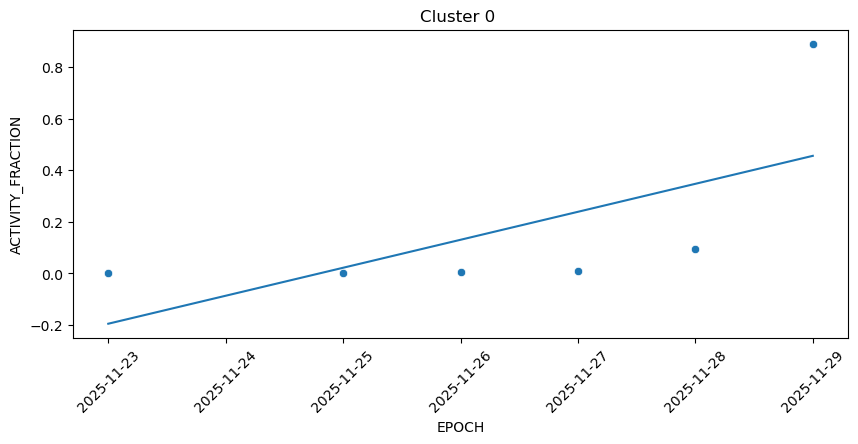

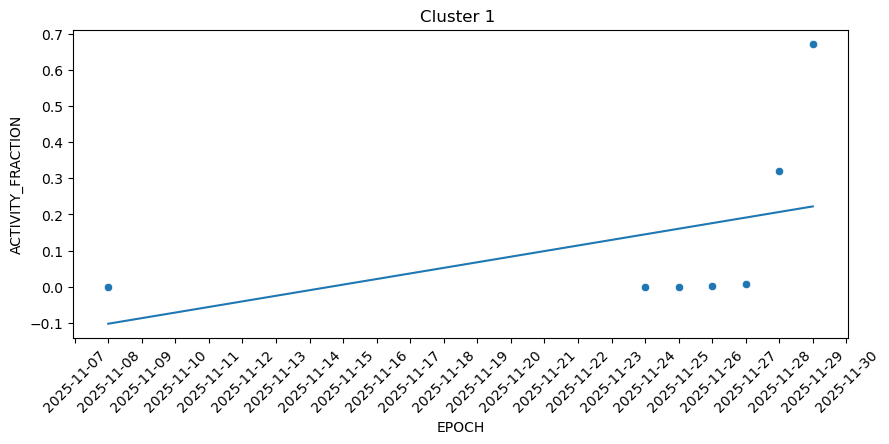

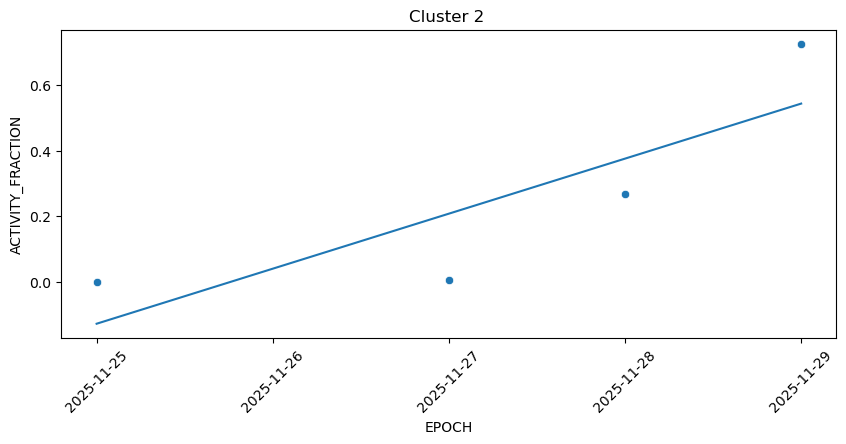

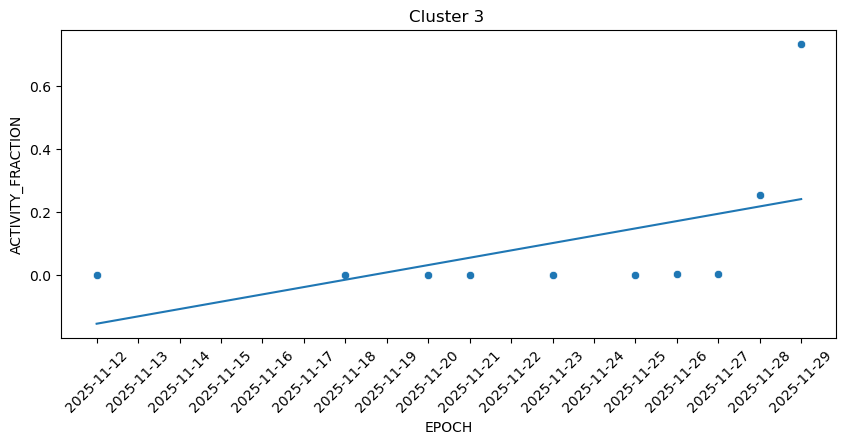

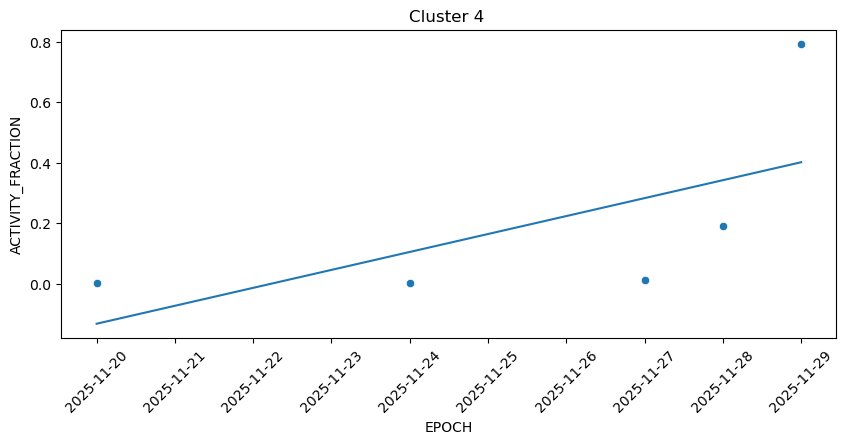

In [23]:
import matplotlib.dates as mdates

for cluster in range(activity_df['CLUSTER'].nunique()):

    plt.figure(figsize=(10, 4))
    plt.title(F'Cluster {cluster} ')
    cluster_rows = activity_df[activity_df['CLUSTER'] == cluster].copy()
    
    # Plot raw data points
    sns.scatterplot(data=cluster_rows, x = 'EPOCH', y = 'ACTIVITY_FRACTION')

    # Obtain perticular model for this cluster and plot the regression line
    model = cluster_models[cluster]['Model']

    y_pred = model.predict(cluster_rows[['EPOCH_NUM']])
    plt.plot(cluster_rows['EPOCH'], y_pred)

    # Resolve the date tick label issue
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.DayLocator())

    
    plt.xticks(rotation=45)

#### Cluster Comparison

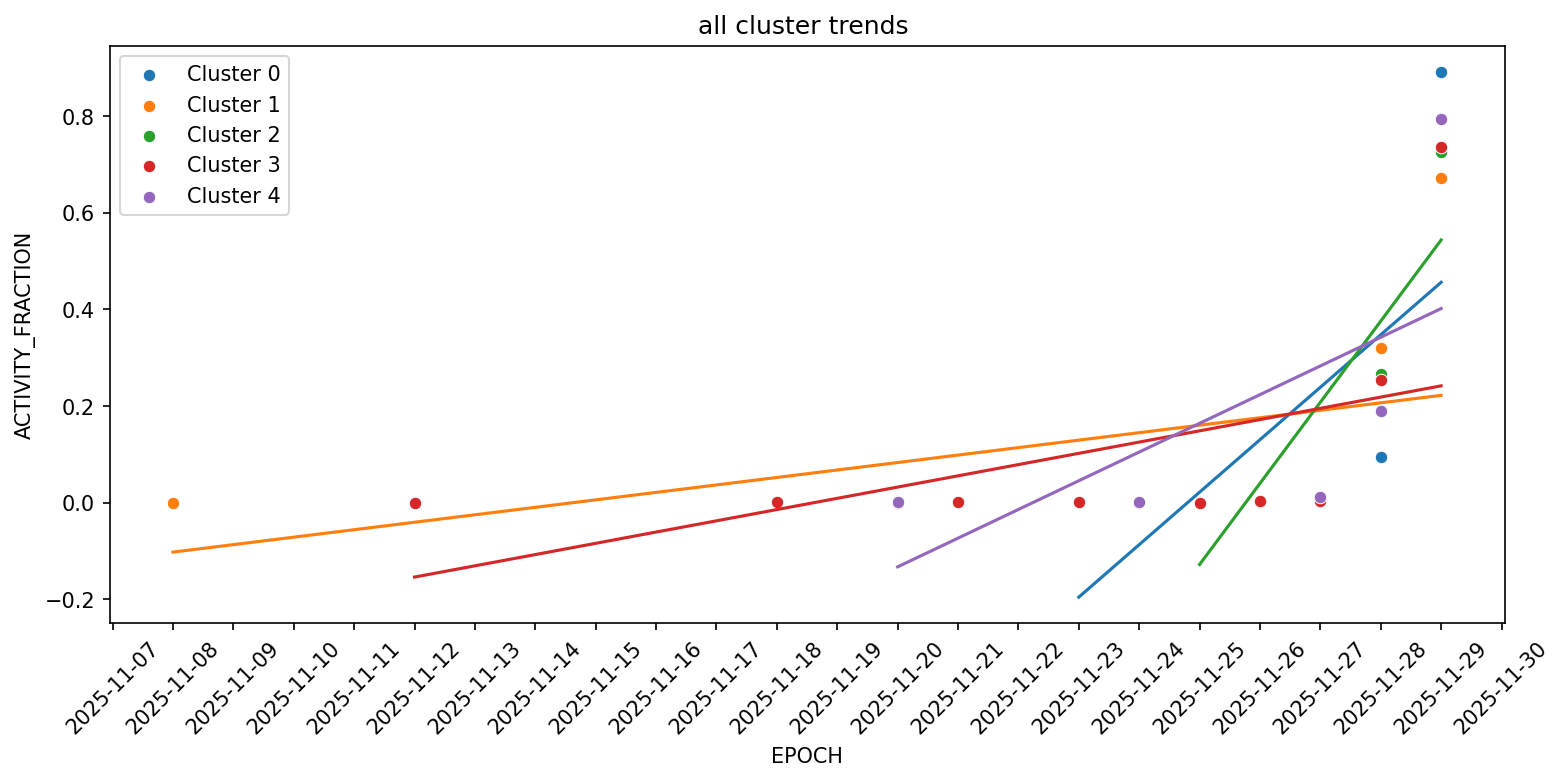

In [24]:

plt.figure(figsize=(12, 5), dpi=150)
for cluster in range(activity_df['CLUSTER'].nunique()):

    plt.title(F'all cluster trends ')
    cluster_rows = activity_df[activity_df['CLUSTER'] == cluster].copy()
    
    # Plot raw data points
    sns.scatterplot(data=cluster_rows, x = 'EPOCH', y = 'ACTIVITY_FRACTION', label=f'Cluster {cluster}')

    # Obtain perticular model for this cluster and plot the regression line
    model = cluster_models[cluster]['Model']

    y_pred = model.predict(cluster_rows[['EPOCH_NUM']])
    plt.plot(cluster_rows['EPOCH'], y_pred)

    # Resolve the date tick label issue
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.DayLocator())
    
    plt.legend()
    plt.xticks(rotation=45)

#### Final Trend Summary

In [25]:
trend_summary = pd.DataFrame(columns=['CLUSTER_ID', 'SLOPE', 'CURRENT_ACTIVITY_FRACTION', 'TREND_TYPE', 'LAUNCH_RISK_LEVEL'])

"""
Define trend type based on 'relative' slope in each cluster : 
    
    normalized = slope / max_slope (bewteen  0 to 1)
    
    > 0.70     → Strong Rising
    0.30–0.70  → Moderate Rising
    0.10–0.30  → Mild Rising
    -0.10–0.10 → Flat
    < -0.10    → Calming
 """


"""
Launch Risk Level (Final Rule Table — Clean & Correct)

Risk Level      | Trend Condition (normalized slope)          | Current Activity Fraction
-------------------------------------------------------------------------------------------------------
High            | Strong Rising or Moderate Rising (>= 0.30)  | > 0.30

Moderate        | Mild Rising (0.00 – 0.29) 
                | OR any near-flat trend with notable activity | 0.10 – 0.35

Low             | Flat / Stable or Calming                    | < 0.10
"""


min_slope = min(d['Slope'] for d in cluster_models)
max_slope = max(d['Slope'] for d in cluster_models)
 
# Use the clustered_model to add the cluster related information obtained through regression
for item in cluster_models:
    cluster = item['Cluster']
    slope = item['Slope']
    current_fraction = item['Current activity fraction']

    # 1. Relative slope strength/trend
    # Scale the relative strength betwwen 0 to 1
    normalized = (slope - min_slope) / (max_slope - min_slope) 

    # Trend classification
    if normalized > 0.70:
        trend_type = 'Strong Rising'
    elif normalized >= 0.30:
        trend_type = 'Moderate Rising'
    elif normalized >= 0.10:
        trend_type = 'Mild Rising'
    elif normalized >= -0.10:
        trend_type = 'Flat'
    else:
        trend_type = 'Calming'


    # 2. Launch risk score classification
    if (normalized >0.3) and (current_fraction >0.3): # Strong & Moderate rising
        risk_level = 'High'
    elif (0.29>=normalized>=0.0) and (0.35>=current_fraction>=0.0): # Mild rising / any rising trend
        risk_level = 'Moderate'
    else: # Flat / Stable / Calming
        risk_level = 'Low'
        

    # Append row data
    trend_summary.loc[len(trend_summary)] = [cluster, slope, current_fraction, trend_type, risk_level]
    
    

In [26]:
trend_summary

,CLUSTER_ID,SLOPE,CURRENT_ACTIVITY_FRACTION,TREND_TYPE,LAUNCH_RISK_LEVEL
0,0,0.10855,0.89105,Moderate Rising,High
1,1,0.01544,0.67200,Flat,Low
2,2,0.16788,0.72639,Strong Rising,High
3,3,0.02327,0.73515,Flat,Low
4,4,0.05938,0.79412,Mild Rising,Low


In [27]:
cluster_models

[{'Cluster': 0,
  'Model': LinearRegression(),
  'Slope': np.float64(0.10855),
  'Intercept': np.float64(-0.19518),
  'Current activity fraction': np.float64(0.89105)},
 {'Cluster': 1,
  'Model': LinearRegression(),
  'Slope': np.float64(0.01544),
  'Intercept': np.float64(-0.10204),
  'Current activity fraction': np.float64(0.672)},
 {'Cluster': 2,
  'Model': LinearRegression(),
  'Slope': np.float64(0.16788),
  'Intercept': np.float64(-0.12773),
  'Current activity fraction': np.float64(0.72639)},
 {'Cluster': 3,
  'Model': LinearRegression(),
  'Slope': np.float64(0.02327),
  'Intercept': np.float64(-0.15367),
  'Current activity fraction': np.float64(0.73515)},
 {'Cluster': 4,
  'Model': LinearRegression(),
  'Slope': np.float64(0.05938),
  'Intercept': np.float64(-0.13255),
  'Current activity fraction': np.float64(0.79412)}]